# Portfolio Opdracht 3: 

# 1. Inleiding

Voor deze opdracht zijn we aangenomen als AI engineers bij VisionWear AI, dit is een technologisch bedrijf dat AI ontwikkeld voor de mode industrie. VisionWear AI werkt samen met webshops, modehuizen en online kleidingplatforms en ontwikkeld hiervoor AI systemen die kleding automatisch kunnen herkennen, beschrijven en nieuwe ontwerpen genereren.

Onze opdracht is om een AI systeem te bouwen dat de volgende dingen kan:

- Kledingstukken automatisch detecteren in afbeeldingen
- Productbeschrijvingen Genereren
- Nieuwe kledingafbeeldingen genereren op basis van tekstuele beschrijvingen. 

VisionWear AI heeft hiervoor een grote dataset verzameld met modefoto's, labels en beschrijvingen, en wij gaan die gebruiken voor de bovenstaande opdracht. We gaan dit doen in 3 delen.
1. Trainen van een model om de kledingstukken en accessoires te identificeren in afbeeldingen.
2. Trainen van een model dat tekstbijschriften te genereren om de kledingstukken te beschrijven.
3. Trainen van een model dat op basis van tekstbijschriften afbeeldingen kan genereren die de kledingstukken beschrijven (met modetermen).

De tekst uit deze opdracht wordt in het engels gegenereerd.

# Setup en Data Inladen

In [14]:
import os

# Omdat de cuda net geupdate is, werd alles opeens instabiel,
# en aangezien tensorflow en pytorch een hekel aan elkaar hebben, 
# moest ik deze workaround gebruiken,
# en gwn memory reserven voor beide frameworks
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Dank aan deze stackoverflow post die uitlegde ik fatsoenlijk mn cuda libraries moest linken,
# BRON: https://stackoverflow.com/questions/13428910/how-to-set-the-environment-variable-ld-library-path-in-linux 
os.environ['LD_LIBRARY_PATH'] = '/usr/lib:/opt/cuda/targets/x86_64-linux/lib'

import nlpaug.augmenter.word as naw
import spacy

# Memory limit fix voor tensorflow, zodat er genoeg VRAM overblijft voor pytorch
# Dankjewel aan Slingacademy voor deze uitleg en fix, 
# want zonder deze fix was het onmogelijk om beide frameworks te gebruiken op dezelfde GPU
# Omdat Tensforflow en Pytorch zo hungry is voor VRAM
# BRON: https://www.slingacademy.com/article/optimizing-memory-allocation-with-tensorflow-config/#preallocating-gpu-memory 
tensorflow_vram_limit = 4048
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:

        tf.config.set_logical_device_configuration(
            gpus[0], [tf.config.LogicalDeviceConfiguration(memory_limit=tensorflow_vram_limit)]
        )
        print(f"TensorFlow beperkt tot {tensorflow_vram_limit}")
    except: pass

import torch
from transformers import (
    pipeline, 
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    Trainer, 
    TrainingArguments, 
    AutoConfig,
    DataCollatorWithPadding,
    AutoModelForMaskedLM
)

print(f"Kan Pytorch bij de rest van de 12GB VRAM: {torch.cuda.is_available()}")

Kan Pytorch bij de rest van de 12GB VRAM: False


In [15]:
# Inladen van libraries
# iets in de volgorde zorgt ervoor dat er geen problemen zijn met cuda libraries,
# dus laat de volgorde zo staan AUB.
import cv2
import os
import re
import gc
import random
import time
from pathlib import Path
from collections import Counter
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import IPython.display as ipd
import numpy as np
import pandas as pd

from scipy.sparse import csr_matrix, hstack

from matplotlib import patches

from tqdm.auto import tqdm

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.utils import class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import plot_model

from datasets import Dataset

from torchview import draw_graph 

In [16]:
# En stellen hier een random state variable in, hierdoor blijven onze splits, 
# maar ook de modellering die daarbij komt kijken consistent met een set seed.
def set_seeds(seed=65):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # Voor volledige GPU determinisme (waarschuwing: kan training vertragen)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_seeds(65)

RANDOM_STATE = 42

pd.set_option('display.max_columns', None)

In [17]:
BASE_DIR = Path.cwd()

TRAIN_DIR = BASE_DIR / "Train"
TEST_DIR = BASE_DIR / "Test"

train_images_dir = TRAIN_DIR / "images"
train_labels_dir = TRAIN_DIR / "labels"

test_images_dir = TEST_DIR / "images"

parsed_data = []

for img_path in train_images_dir.glob("*"):
    if img_path.suffix.lower() not in [".jpg"]:
        continue

    label_path = train_labels_dir / f"{img_path.stem}.txt"

    with open(label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            parsed_data.append(
                {
                    "image_path": str(img_path),
                    "label_path": str(label_path),
                    "image_name": img_path.name,
                    "class_id": int(parts[0]),
                    "center_x": float(parts[1]),
                    "center_y": float(parts[2]),
                    "width": float(parts[3]),
                    "height": float(parts[4]),
                }
            )

# Maak het DataFrame aan
train_df = pd.DataFrame(parsed_data)

In [18]:
def check_dataset(df, label):
    """
    Print informatie over het DataFrame en de bijbehorende Wav-bestanden,
    zoals het aantal records, ontbrekende waarden en het aantal Wav-bestanden in de directory.

    Args:
        df (pd.DataFrame): Het DataFrame met de kolom 

    Returns:
        Een overzicht van de dataset, inclusief het aantal records, ontbrekende waarden en het aantal Wav-bestanden.
    """

    display(df.head(1))
    print(f"{label.lower()}_df shape = {df.shape}")
    
    # We gebruiken rglob om recurively door de files te kijken
    # hierdoor hoeven we niet specifiek te kijken voor genre mappen
    # en meer robuust voor het geval een files is misplaced

    print("\nOntbrekende waarden in dataframe:")
    print(df.isna().sum())

In [19]:
print(f"Dimensies van het DataFrame: {train_df.shape}")


print("Aantal unieke afbeeldingen:", train_df["image_name"].nunique())
check_dataset(train_df, "Train")

Dimensies van het DataFrame: (8298, 8)
Aantal unieke afbeeldingen: 2145


,image_path,label_path,image_name,class_id,center_x,center_y,width,height
0,/home/beef/Documents/GitHub/Deep-Learning-3/Tr...,/home/beef/Documents/GitHub/Deep-Learning-3/Tr...,1.jpg,8,0.68875,0.639167,0.3025,0.118333


train_df shape = (8298, 8)

Ontbrekende waarden in dataframe:
image_path    0
label_path    0
image_name    0
class_id      0
center_x      0
center_y      0
width         0
height        0
dtype: int64


Train_DF en Train Wav Files:
- train_df shape = (8298, 8)
- Aantal train image files op schijf: 2145

| Kolomnaam | Uitleg | 
| -| -|
| image_path| Bevat het pad naar de image file | 
|label_path | Bevat het pad naar het txtbestand met de afmetingen voor de image | 
| image_name| Bevat de naam van het corresponderende image file | 
| class_id| Bevat de numerieke categorie van het clothing item|
| center_x| Bevat het centrale x coordinaat van de bounding box |
| center_y| Bevat het centrale y coordinaat van de bounding box|
| width| Bevat de breedte van de bounding box|
| height| Bevat de hoogte van de bounding box|



# 2. EDA

In [20]:
# Hier hebben we vaste kleuren ingesteld voor de genres, 
# zodat alles consistent blijft qua overzicht en graphics.
clothing_colors = {
    'sunglass': "#ff0000",  
    'hat': "#ff7b00",
    'jacket': "#a29a00", # keb geel donkerder gemaakt, anders was de witte txt niet te zien
    'shirt': "#b7ff00",  
    'pants': "#00FF6A",   
    'shorts': "#00ffe5",  
    'skirt': "#0000ff",     
    'dress': "#6f00ff",
    'bag': "#d400ff", 
    'shoe': "#ff0090"}

clothing_labels = {
    0: "sunglass",
    1: "hat",
    2: "jacket",
    3: "shirt",
    4: "pants",
    5: "shorts",
    6: "skirt",
    7: "dress",
    8: "bag",
    9: "shoe",
}

## 2.x. Clothing Class Aantallen

/tmp/ipykernel_54854/1616960100.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


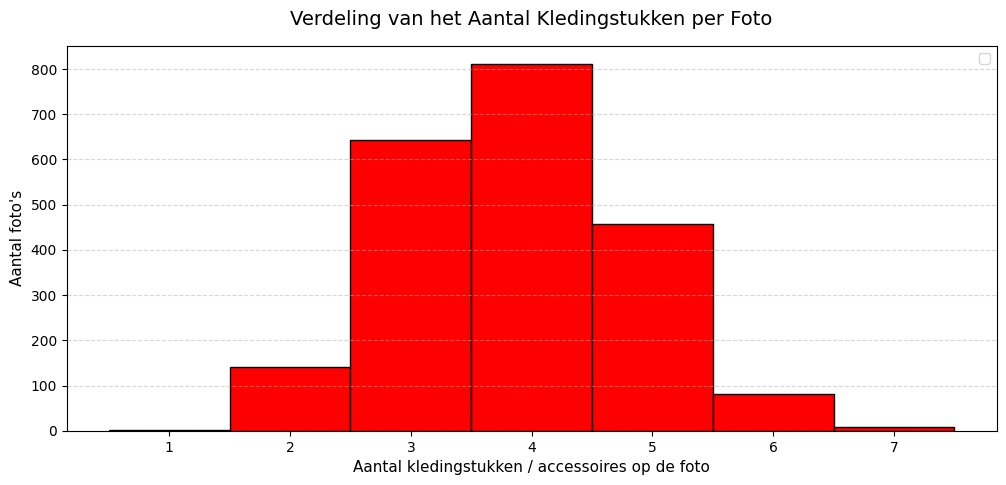

In [21]:
df_summary = train_df.groupby('image_name').agg(
    totaal_tags=('class_id', 'count')
).reset_index()

max_stukken = df_summary['totaal_tags'].max()
min_stukken = df_summary['totaal_tags'].min()

plt.figure(figsize=(12, 5))

sns.histplot(
    data=df_summary, 
    x='totaal_tags', 
    discrete=True, 
    kde=False, 
    color="#ff0000", 
    alpha=1
)

plt.title('Verdeling van het Aantal Kledingstukken per Foto', fontsize=14, pad=15)
plt.xlabel('Aantal kledingstukken / accessoires op de foto', fontsize=11)
plt.ylabel('Aantal foto\'s', fontsize=11)
plt.xticks(range(int(min_stukken), int(max_stukken) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()

plt.show()

analyse

shoe        :  2081
shirt       :  1486
bag         :  1188
jacket      :   777
skirt       :   697
dress       :   550
pants       :   508
shorts      :   395
sunglass    :   343
hat         :   273


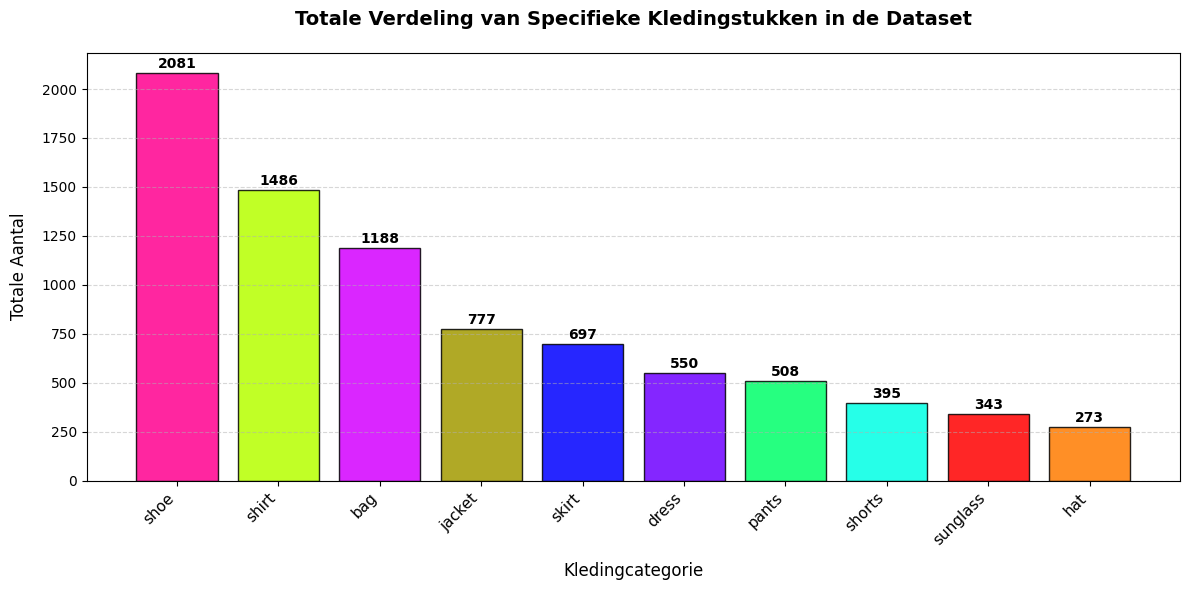

In [22]:
train_df['class_name'] = train_df['class_id'].map(clothing_labels)


counts = train_df['class_name'].value_counts()
percentages = train_df['class_name'].value_counts(normalize=True) * 100

for name in counts.index:
    print(f"{name.ljust(12)}: {str(counts[name]).rjust(5)}")


plot_colors = [clothing_colors.get(name, "#333333") for name in counts.index]

plt.figure(figsize=(12, 6))

bars = plt.bar(counts.index, counts.values, color=plot_colors, edgecolor='black', alpha=0.85)


for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 10, 
        f'{int(yval)}', 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        weight='bold'
    )

plt.title('Totale Verdeling van Specifieke Kledingstukken in de Dataset', fontsize=14, pad=20, weight='bold')
plt.xlabel('Kledingcategorie', fontsize=12, labelpad=10)
plt.ylabel('Totale Aantal', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Zoals we hierboven zien zijn de vershcillende kledingstukken en accesoires niet gelijk verdeeld over de dataset. We zien dat schoenen veruit het meest voorkomen, maar dit is ook logisch aangezien er van de overige categoreieen geen alternatief is voor shoes, bevalve barefoot maar dat is geen categorie.

Verder zien we ook dat van de accesoiries dat bag veruit het meest voorkomt, daarna pas sunglasses en hats. 

Toch als we hieronder gaan kijken naar de verdelingen van de kleding verdeeld over de algemene soorten:

- Legwear
    - Pants
    - Shorts
    - Skirt
- Torsokleding
    - Dress
    - Shirt
- Accesseroires
    - Bag
    - Sunglasses
    - Hat
- Footwear
    - Shoes
- Outerwear
    - Jacket

Toch een redelijke verdeling over deze kledingsoorten met een redelijk gelijke verdeling. 

We hebben hierbij ook dress bij legwear en torsokleding gezet, dresses functioneren als beide en als deze ontbrak uit een van de 2, zou dat duiden op mensen zonder broek en/of shirt.

Verder zien we dat outerwear/jacket veruit het minste is, maar ook logisch aangezien deze naast accesoires de optionele kledingstuk is.

Verder uit accessoires zien we dat bags veruit het meeste voorkomen.

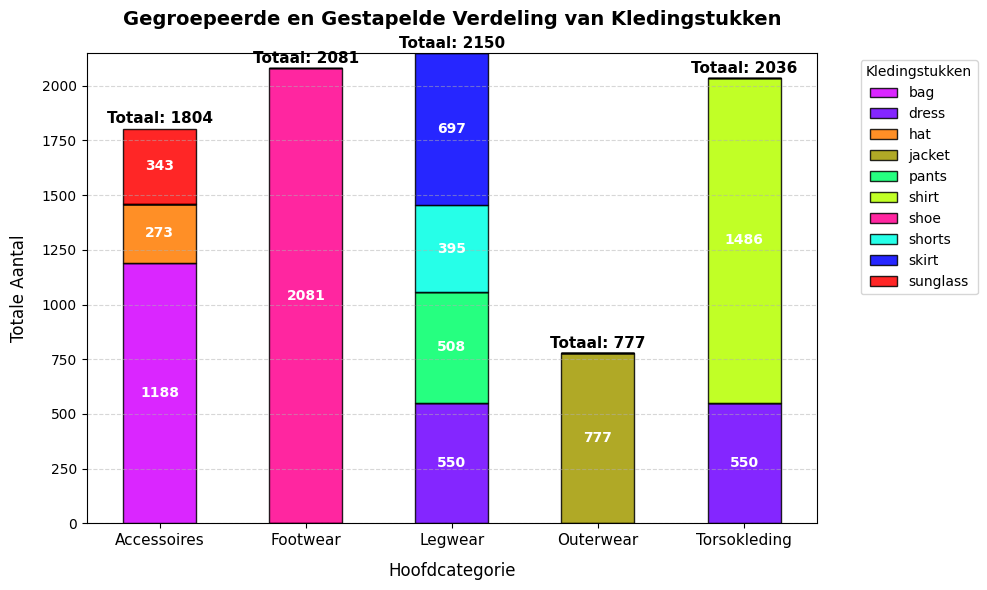

In [39]:


# 1. Maak de mapping (zonder duplicaten)
hoofdgroepen_mapping = {
    'pants': 'Legwear',
    'shorts': 'Legwear',
    'skirt': 'Legwear',
    'shirt': 'Torsokleding',
    'bag': 'Accessoires',
    'sunglass': 'Accessoires',
    'hat': 'Accessoires',
    'shoe': 'Footwear',
    'jacket': 'Outerwear'
}

# 2. Maak een kopie van de data voor de plot om je originele train_df niet te vervuilen
plot_df = train_df.copy()

# Pas de standaard mapping toe (dress valt hier nu nog buiten en wordt 'Overig')
plot_df['hoofdgroep'] = plot_df['class_name'].map(hoofdgroepen_mapping).fillna('Overig')

# 3. SPLIT DE JURKEN: Pak alle jurken eruit
dresses = plot_df[plot_df['class_name'] == 'dress'].copy()

if not dresses.empty:
    # Maak één set jurken voor Torsokleding
    dresses_torso = dresses.copy()
    dresses_torso['hoofdgroep'] = 'Torsokleding'
    
    # Maak één set jurken voor Legwear
    dresses_legwear = dresses.copy()
    dresses_legwear['hoofdgroep'] = 'Legwear'
    
    # Verwijder de originele 'dress' rijen uit plot_df (die stonden op 'Overig')
    plot_df = plot_df[plot_df['class_name'] != 'dress']
    
    # Voeg de twee nieuwe gesplitste groepen toe aan de plot data
    plot_df = pd.concat([plot_df, dresses_torso, dresses_legwear], ignore_index=True)


# 4. Maak de kruistabel (exact zoals je al had)
grouped_data = pd.crosstab(plot_df['hoofdgroep'], plot_df['class_name'])

# Zorg dat de kleuren kloppen
current_columns = grouped_data.columns
plot_colors = [clothing_colors.get(name, "#333333") for name in current_columns]

# 5. Het plotten (exact jouw code, maar nu met de gesplitste 'dress')
fig, ax = plt.subplots(figsize=(10, 6))
grouped_data.plot(kind='bar', stacked=True, color=plot_colors, edgecolor='black', alpha=0.85, ax=ax)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(
            x + width/2, 
            y + height/2,  
            f'{int(height)}', 
            ha='center', 
            va='center', 
            fontsize=10, 
            weight='bold',
            color='white'  
        )

for i, total in enumerate(grouped_data.sum(axis=1)):
    ax.text(i, total + 10, f'Totaal: {int(total)}', ha='center', va='bottom', weight='bold', fontsize=11)

plt.title('Gegroepeerde en Gestapelde Verdeling van Kledingstukken', fontsize=14, pad=20, weight='bold')
plt.xlabel('Hoofdcategorie', fontsize=12, labelpad=10)
plt.ylabel('Totale Aantal', fontsize=12, labelpad=10)
plt.xticks(rotation=0, fontsize=11) 
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Kledingstukken", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

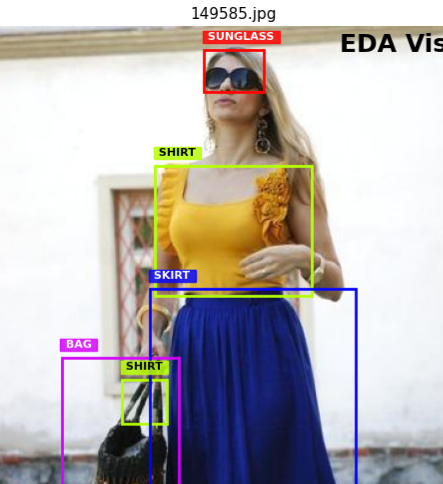

## 2.x. Fotos

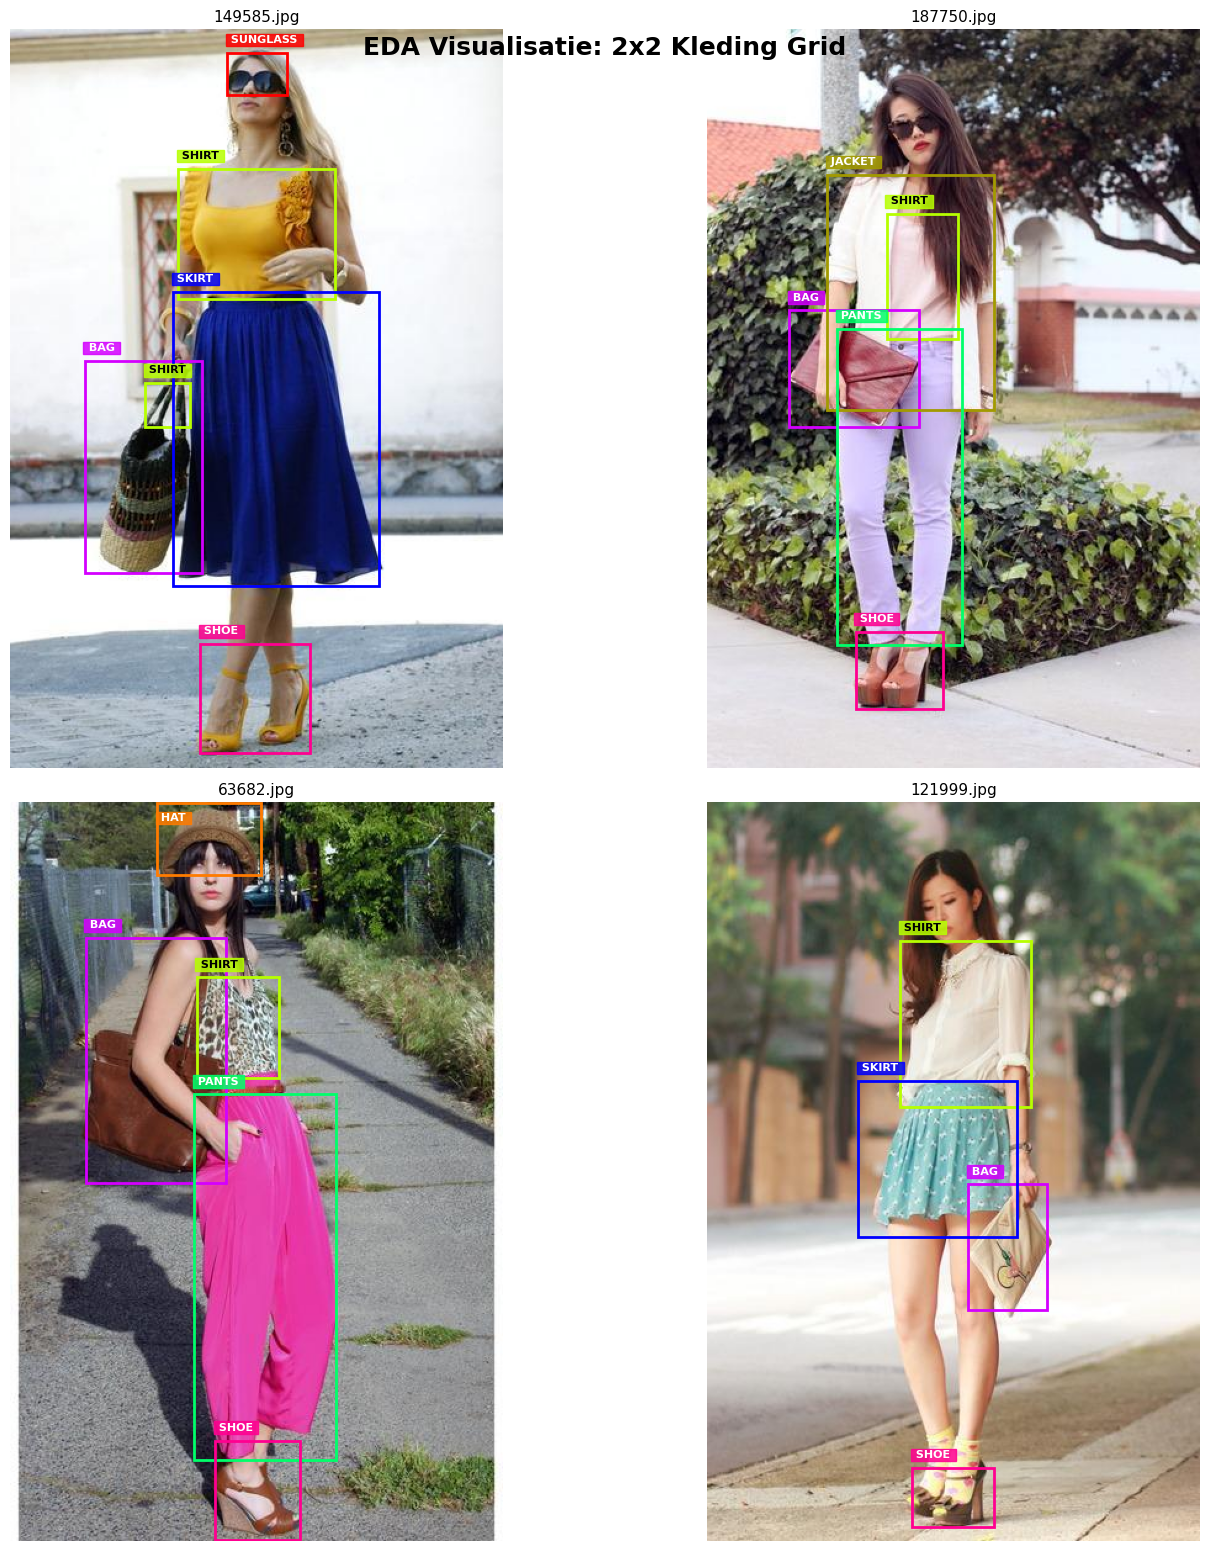

In [ ]:


def plot_fashion_grid(df):
    # 1. Kies willekeurig 4 unieke afbeeldingen uit de dataset
    unique_images = df["image_name"].unique()
    chosen_images = np.random.choice(unique_images, size=4, replace=False)
    
    # 2. Maak een 2x2 grid van subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 16))
    axes = axes.flatten()  # Maak van de 2x2 matrix een platte lijst van 4 opeenvolgende assen
    
    # 3. Loop door de 4 gekozen afbeeldingen en hun bijbehorende subplot-as
    for i, image_name in enumerate(chosen_images):
        ax = axes[i]
        
        # Filter de data voor deze specifieke afbeelding
        img_objects = df[df["image_name"] == image_name]
        img_path = img_objects.iloc[0]['image_path']
        
        # Afbeelding inladen en converteren naar RGB
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        img_h, img_w, _ = image.shape
        
        # Toon de afbeelding op de huidige as
        ax.imshow(image)
        
        # 4. Teken alle bounding boxes voor deze afbeelding
        for _, row in img_objects.iterrows():
            c_name = row["class_name"]
            box_color = clothing_colors.get(c_name, "#FFFFFF")
            
            # Bereken de coördinaten (omgerekend vanuit YOLO/genormaliseerd formaat)
            w = row["width"] * img_w
            h = row["height"] * img_h
            xmin = (row["center_x"] - row["width"] / 2) * img_w
            ymin = (row["center_y"] - row["height"] / 2) * img_h
            
            # Rechthoek aanmaken en toevoegen
            rect = patches.Rectangle(
                (xmin, ymin),
                w,
                h,
                linewidth=2.0,
                edgecolor=box_color,
                facecolor="none",
            )
            ax.add_patch(rect)
            
            # Labeltekst kleur bepalen voor leesbaarheid
            text_color = "black" if c_name in ["shirt", "shorts"] else "white"
            
            # Label boven de bounding box plaatsen
            ax.text(
                xmin,
                ymin - 8 if ymin - 8 > 0 else ymin + 15,  # Voorkomt dat tekst buiten beeld valt bij de bovenrand
                f" {c_name.upper()} ",
                color=text_color,
                fontsize=8,
                weight="bold",
                bbox=dict(facecolor=box_color, edgecolor=box_color, alpha=0.85, pad=1),
            )
        
        # Titel en opmaak per subplot
        ax.set_title(f"{image_name}", fontsize=11, pad=5)
        ax.axis("off")
        
    # Algemene titel over het hele grid heen
    plt.suptitle("EDA Visualisatie: 2x2 Kleding Grid", fontsize=18, weight="bold", y=0.95)
    plt.tight_layout()
    plt.show()

# Aanroepen van de nieuwe grid functie
plot_fashion_grid(train_df)

analyse

In [26]:
#from datasets import load_dataset

##ds = load_dataset("tomytjandra/h-and-m-fashion-caption-12k")

# Opdracht 2: Objectdetectie
 In deze deelopdracht werk je uitsluitend met de images en labels uit de data voor
deel 1. Bouw en train een objectdetectie model om de tien klassen kleding en
modeaccessoires in de dataset te detecteren en hun locaties te voorspellen met
behulp van bounding-boxes.

 Beschrijf in je eigen woorden hoe je model voorspellingen doet.

 Beschrijf hoe je de afbeeldingen voorbewerkt.

 Beschrijf in detail welke stappen, indien aanwezig, je onderneemt voor feature
engineering.

 Onderbouw je keuzes van de hyperparameters, de keuze van de optimizer en het
aantal trainingsepochs.

 Beschrijf de lossfunctie voor dit model in je eigen woorden en hoe deze werk

# 3. Object Detectie Model

In [27]:
from sklearn.model_selection import train_test_split

# 1. Haal alle unieke afbeeldingspaden op en zet ze om naar een standaard Python lijst (.tolist())
unieke_afbeeldings_paden = train_df['image_path'].unique().tolist()

# 2. Splits de paden (80% training, 20% validatie) met jouw seed
train_paths, val_paths = train_test_split(
    unieke_afbeeldings_paden, 
    test_size=0.2, 
    random_state=65
)

# 3. Schrijf de paden naar train.txt en val.txt
with open(BASE_DIR / 'train.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(train_paths))

with open(BASE_DIR / 'val.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(val_paths))

print(f"Treinfoto's vastgelegd in train.txt: {len(train_paths)}")
print(f"Validatiefoto's vastgelegd in val.txt: {len(val_paths)}")

Treinfoto's vastgelegd in train.txt: 1716
Validatiefoto's vastgelegd in val.txt: 429


In [28]:
from sklearn.model_selection import train_test_split

# 1. Haal alle unieke afbeeldingspaden op en zet ze om naar een standaard Python lijst (.tolist())
unieke_afbeeldings_paden = train_df['image_path'].unique().tolist()

# 2. Splits de paden (80% training, 20% validatie) met jouw seed
train_paths, val_paths = train_test_split(
    unieke_afbeeldings_paden, 
    test_size=0.2, 
    random_state=65
)

# 3. Schrijf de paden naar train.txt en val.txt
with open(BASE_DIR / 'train.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(train_paths))

with open(BASE_DIR / 'val.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(val_paths))

print(f"Treinfoto's vastgelegd in train.txt: {len(train_paths)}")
print(f"Validatiefoto's vastgelegd in val.txt: {len(val_paths)}")

Treinfoto's vastgelegd in train.txt: 1716
Validatiefoto's vastgelegd in val.txt: 429


In [29]:
yaml_content = f"""
path: {str(BASE_DIR)}  # Het hoofdpad van je project
train: train.txt       # Verwijst naar het zojuist gemaakte train-tekstbestand
val: val.txt           # Verwijst naar het zojuist gemaakte val-tekstbestand
test: Test/images      # Map met de testfoto's voor je Kaggle submission

nc: 10

names:
  0: sunglass
  1: hat
  2: jacket
  3: shirt
  4: pants
  5: shorts
  6: skirt
  7: dress
  8: bag
  9: shoe
"""

# Schrijf het YAML-bestand weg
yaml_path = BASE_DIR / "fashion_data.yaml"
with open(yaml_path, "w", encoding="utf-8") as f:
    f.write(yaml_content.strip())

print(f"Configuratiebestand succesvol aangemaakt op: {yaml_path}")

Configuratiebestand succesvol aangemaakt op: /home/beef/Documents/GitHub/Deep-Learning-3/fashion_data.yaml


In [30]:
import torch

# Voeg dit toe vóór model.train()
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
# Als dat niet genoeg is, kun je cuDNN eventueel compleet uitschakelen met:
# torch.backends.cudnn.enabled = False

In [31]:
import gc
import torch
from ultralytics import YOLO

# VRAM optimaal vrijmaken voor de start
gc.collect()
torch.cuda.empty_cache()

# 1. Laad het pre-trained YOLOv8 Medium model
model = YOLO("yolov8m.pt")

# 2. Start de training op jouw modedataset met de boxes
results = model.train(
    data=str(yaml_path),      # Het pad naar je zojuist gemaakte yaml
    epochs=50,                # 50 complete rondes door de dataset
    imgsz=640,                # Formaat van de afbeeldingen
    batch=16,                 # Aantal foto's per stap (veilig voor jouw VRAM)
    optimizer="AdamW",        # Snelste en meest stabiele optimizer
    lr0=0.001,                # De learning rate
    weight_decay=0.0005,      # Voorkomt overfitting
    device=0,                 # Forceer training op je CUDA GPU
    workers=2,                # Voorkomt dat je Arch Linux dataloader crasht
    seed=65                   # Jouw vaste seed
)

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

# YOLO slaat resultaten op in 'runs/detect/train/' (of train2, train3 als je vaker runt)
# We zoeken de meest recente map op
runs_dir = Path("runs/detect")
latest_train_dir = sorted(runs_dir.glob("train*"))[-1]

results_png_path = latest_train_dir / "results.png"

if results_png_path.exists():
    img = cv2.imread(str(results_png_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(14, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.title("YOLOv8 Trainingsresultaten & Evaluatiestatistieken", fontsize=14, pad=15)
    plt.show()
else:
    print(f"Kon results.png niet vinden in {latest_train_dir}")

# Opdracht 4: Beeldgeneratie
 In deze deelopdracht werk je met de H&M images en captions dataset.

 Voor deze opdracht kies je een voorgetraind model van Hugging Face en fine-tune dit
op de afbeeldingen en tekstdataset.

 Geef de naam op van de modelarchitectuur die je hebt gekozen en de dataset
waarop deze vooraf is getraind.

 Je model moet een Engels tekstbijschrift als input gebruiken en een afbeelding als
output maken.

 Beschrijf in detail de stappen die worden genomen bij het finetunen van dit vooraf
getraind model.

 Beschrijf de componenten van dit model.

 Beschrijf in je eigen woorden hoe het model afbeeldingen maakt en welke lossfunctie
het gebruikt.

 Onderbouw je keuzes van de hyperparameters, de keuze van de optimizer en het
aantal trainingsepoch

# Opdracht 5: Implementatie

 Maak een eenvoudige app die een foto als input gebruikt, kledingstukken en
modeaccessoires detecteert en hun locatie geeft, en tekstbeschrijvingen genereert
van elk kledingstuk in de afbeelding. Gebruik de modellen die je in de voorgaande
opdrachten hebt getraind/gefinetuned.

 De app gebruikt een foto als input en voorspelt de locatie van elk afzonderlijk
kledingstuk en modeaccessoire. Vervolgens worden de individuele
kledingstukken/mode-items voorzien van bijschriften. De bijschriften moeten voor
elk afzonderlijk gedetecteerd item afzonderlijk worden gegenereerd.

 Let op: Je hoeft deze app niet te deployen. Je hoeft alleen maar de modellen in jouw
notebook uit te voeren en de voorspellingen op de juiste manier te combineren.

 Geef een samenvatting van de uitkomsten van het modelleren.
o Geef een beknopt overzicht van de resultaten.

o (Voor deel 1) Toon je scores op Kaggle en laat zien wat de resultaten waren
van je verbeteringen op je score op Kaggle.

o (Voor deel 2 & 3) Geef voorbeelden van je getrainde modellen in actie en
evalueer hun prestaties.

o Geef een voorbeeld/voorbeelden van hoe je app kleding en modeaccessoires
detecteert en geschikte bijschriften genereert voor elk gedetecteerd ite

# Opdracht 6: Conclusie en aanbevelingen
 Beschrijf het modelleringsproces voor deze opdracht. Wat waren de uitdagingen
daarmee?

 Wat zou je aanbevolen gebruik zijn van de modellen die je hebt getraind?

 Wat zouden je aanbevelingen zijn met betrekking tot het soort afbeeldingen/data
waarop je deze modellen kunt gebruiken?

 Zijn de resultaten van je modellen accuraat/betrouwbaar? Wat kan er gedaan
worden om deze te verbeteren?